```{contents}
```

## Cost Function

### 1. **Gradient Boosting Regressor (GBR)**

**Purpose:** Minimize prediction error for continuous targets.

#### Common Loss Functions:

1. **Mean Squared Error (MSE)**

$$
L(y, \hat{y}) = \frac{1}{n}\sum_{i=1}^n (y_i - \hat{y}_i)^2
$$

* Measures squared differences between predicted and true values.
* Gradient w\.r.t prediction:

$$
\frac{\partial L}{\partial \hat{y}_i} = -2 (y_i - \hat{y}_i)
$$

* **Pseudo-residuals:** $r_i = y_i - \hat{y}_i$ → what each tree fits.

2. **Mean Absolute Error (MAE)**

$$
L(y, \hat{y}) = \frac{1}{n} \sum_{i=1}^n |y_i - \hat{y}_i|
$$

* More robust to outliers.
* Gradient:

$$
\frac{\partial L}{\partial \hat{y}_i} = -\text{sign}(y_i - \hat{y}_i)
$$

* Trees fit the **direction** of error instead of squared magnitude.

3. **Huber Loss (Combination of MSE & MAE)**

$$
L_\delta(y, \hat{y}) = 
\begin{cases} 
\frac{1}{2}(y-\hat{y})^2 & \text{if } |y-\hat{y}| \le \delta \\ 
\delta \cdot (|y-\hat{y}| - \frac{\delta}{2}) & \text{otherwise} 
\end{cases}
$$

* Smooth near zero, linear for large errors → robust and stable.

**Workflow for GBR:**

1. Compute pseudo-residuals: negative gradient of chosen loss.
2. Fit tree to residuals.
3. Update model: $F_m = F_{m-1} + \nu \gamma_m h_m(x)$.

---

### 2. **Gradient Boosting Classifier (GBC)**

**Purpose:** Minimize prediction error for categorical targets.

#### Common Loss Functions:

1. **Binary Cross-Entropy / Log Loss**

$$
L(y, \hat{p}) = - \frac{1}{n} \sum_{i=1}^n \big( y_i \log \hat{p}_i + (1 - y_i) \log (1 - \hat{p}_i) \big)
$$

* $y_i \in \{0,1\}$, $\hat{p}_i = \sigma(F(x_i))$
* Negative gradient (pseudo-residuals):

$$
r_i = y_i - \hat{p}_i
$$

* Each tree tries to fit $r_i$ → improves probability estimates.

2. **Multiclass Cross-Entropy**

$$
L(y, \hat{p}) = - \sum_{i=1}^n \sum_{k=1}^K y_{ik} \log \hat{p}_{ik}
$$

* $y_{ik} = 1$ if sample $i$ belongs to class $k$, else 0.
* $\hat{p}_{ik} = \text{softmax}(F_k(x_i))$
* Pseudo-residuals for each class:

$$
r_{ik} = y_{ik} - \hat{p}_{ik}
$$

* Trees are trained **per class** to fit residuals.

---

**Intuition**

* **GBR:** Loss is continuous → residual = actual - predicted.
* **GBC:** Loss is probabilistic → residual = observed probability - predicted probability.
* Gradient boosting **fits a tree to the negative gradient of the loss** in every iteration.
* Choice of loss determines **robustness, sensitivity to outliers, and type of problem**.

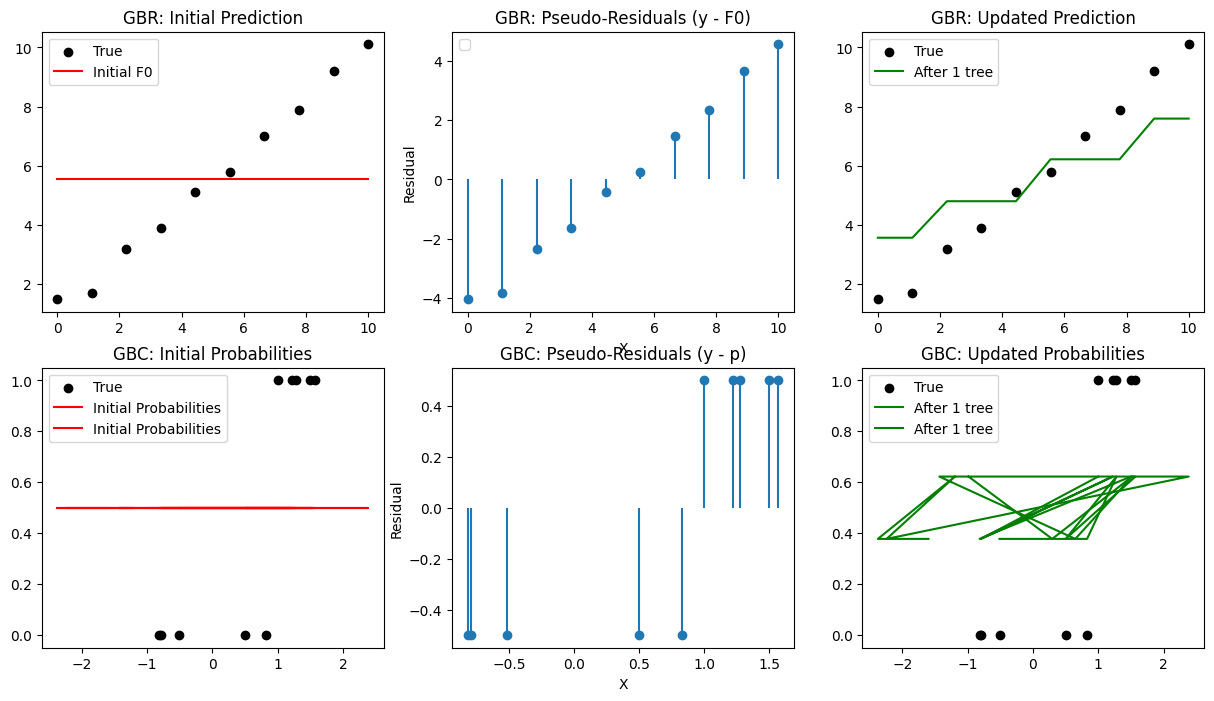

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.datasets import make_classification
from sklearn.preprocessing import LabelBinarizer
from scipy.special import expit  # sigmoid
import warnings
warnings.filterwarnings("ignore")

# -------------------------------
# Part 1: Gradient Boosting Regressor (GBR)
# -------------------------------
# Dataset
X_reg = np.linspace(0, 10, 10).reshape(-1,1)
y_reg = np.array([1.5, 1.7, 3.2, 3.9, 5.1, 5.8, 7.0, 7.9, 9.2, 10.1])

# Initialize prediction (F0)
F0 = np.mean(y_reg)
Fm = np.full_like(y_reg, F0, dtype=float)

plt.figure(figsize=(15,8))
plt.subplot(2,3,1)
plt.scatter(X_reg, y_reg, color='black', label='True')
plt.plot(X_reg, Fm, color='red', label='Initial F0')
plt.title("GBR: Initial Prediction")
plt.legend()

# Compute pseudo-residuals (MSE)
residuals = y_reg - Fm
plt.subplot(2,3,2)
plt.stem(X_reg, residuals, basefmt=" ")
plt.title("GBR: Pseudo-Residuals (y - F0)")
plt.xlabel("X")
plt.ylabel("Residual")
plt.legend()

# Fit a weak learner
tree = DecisionTreeRegressor(max_depth=2)
tree.fit(X_reg, residuals)
pred = tree.predict(X_reg)
Fm += 0.5 * pred  # learning_rate=0.5

plt.subplot(2,3,3)
plt.scatter(X_reg, y_reg, color='black', label='True')
plt.plot(X_reg, Fm, color='green', label='After 1 tree')
plt.title("GBR: Updated Prediction")
plt.legend()



# -------------------------------
# Part 2: Gradient Boosting Classifier (GBC)
# -------------------------------
# Binary classification dataset
X_clf, y_clf = make_classification(
    n_samples=10,
    n_features=2,      # must be >= log2(n_classes*n_clusters_per_class)
    n_informative=2,
    n_redundant=0,
    n_repeated=0,
    n_classes=2,
    random_state=0
)
y_clf = y_clf.reshape(-1,1)

# Initialize prediction (F0 for log-odds)
p0 = np.mean(y_clf)
F0 = np.log(p0/(1-p0))
Fm = np.full_like(y_clf, F0, dtype=float)

# Compute pseudo-residuals
p = expit(Fm)  # sigmoid probabilities
residuals = y_clf - p


plt.subplot(2,3,4)
plt.scatter(X_clf[:,0], y_clf, color='black', label='True')

plt.plot(X_clf, p, color='red', label='Initial Probabilities')
plt.title("GBC: Initial Probabilities")
plt.legend()

plt.subplot(2,3,5)
plt.stem(X_clf[:,0], residuals, basefmt=" ")
plt.title("GBC: Pseudo-Residuals (y - p)")
plt.xlabel("X")
plt.ylabel("Residual")

# Fit weak learner
tree = DecisionTreeRegressor(max_depth=2)
tree.fit(X_clf, residuals)
pred = tree.predict(X_clf)
Fm = Fm.flatten()       # shape (10,)
pred = pred.flatten()   # shape (10,)
Fm += 0.5 * pred        # works

Fm += 0.5 * pred  # learning_rate=0.5
p = expit(Fm)

plt.subplot(2,3,6)
plt.scatter(X_clf[:,0], y_clf, color='black', label='True')
plt.plot(X_clf, p, color='green', label='After 1 tree')
plt.title("GBC: Updated Probabilities")
plt.legend()
plt.show()
